# **Sistema de triaje médico automático**

#### **Grupo:**

Hanser Rubén Guzmán Luna, Iosune Íñigo Marco, Teodoro Alcántara Dormido

#### **Descripción:**
Este notebook implementa, entrena y evalúa los modelos del sistema descritos en la entrega 2 para las tareas 2, 3 y 4. Para cada conjunto se hace un análisis exploratorio de datos, se entrenan los modelos y se examinan los resultados. Se hace también un estudo de errore de los mismos

#### **Estructura del notebook:**
1. Configuración común
2. T2 - NER
3. T3 - Diagnóstico
4. T4 - Triaje



## 1. Configuración común

Importamos las librerías que vamos a utilizar:

In [ ]:
import json, os, random, re, sys, time, warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from spacy.matcher import PhraseMatcher
from spacy.tokens import Span
from dataclasses import dataclass
import torch
from transformers import MarianMTModel, MarianTokenizer, DataCollatorWithPadding
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate as hf_evaluate # Esta libreria es necesario instalarla a parte en colab
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
import shutil
import joblib

Configuramos algunas variables globales y elecciones de visualización:

In [4]:
# Ignoramos warnings
warnings.filterwarnings("ignore")

# Fijamos el estilo de seaborn para algunas gráficas
sns.set_theme(context="notebook", style="whitegrid")

# Fijamos semilla (aunque luego la fijemos para cada funcion)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Tomamos el directorio base, que es muy util si trabajamos en colab
BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name != "entrenamiento_modelos" and (BASE_DIR / "entrenamiento_modelos").exists():
    BASE_DIR = BASE_DIR / "entrenamiento_modelos"

# Creamos las rutas a los directorios de los datos y de los modelos
DATA_DIR = BASE_DIR / "datos"
MODELS_DIR = BASE_DIR / "modelos"

In [5]:

# Si podemos, utilizamos la GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)

# Fijamos la semilla para PyTorch, aunque no suele ser muy útil
torch.manual_seed(SEED)

Dispositivo: cuda


## 2. T2 - NER de síntomas y enfermedades

**Decisión de diseño.** Tal y como se justifica en la Entrega 2 (sec. 2.1), para T2 elegimos *texto tokenizado* + diccionario. El razonamiento clínico de esta tarea es léxico, no semántico: el médico necesita ver exactamente qué términos detecta el sistema, con su código asociado, y la explicabilidad es un requisito explícito del proyecto. La técnica propuesta consiste en construir gazetteers a partir de las menciones anotadas en SympTEMIST (síntomas) y DISTEMIST (enfermedades), buscarlas en el texto con `spaCy.PhraseMatcher` sobre LEMAS (para absorber plurales y conjugaciones), filtrar solapamientos quedándonos con el span más largo, y aplicar una ventana de negación tipo NegEx.

**Sobre la negación.** Si un síntoma está negado se descarta para la PoC (T3/T4 sólo ven síntomas afirmados). Sin embargo, los datasets DISTEMIST y SympTEMIST anotan menciones textuales sin tener en cuenta la negación lingüística: si el texto dice "no se observa fiebre", la mención "fiebre" está anotada como entidad. Por tanto, evaluamos el extractor con el filtro de negación desactivado (para ser justos con cómmo están anotados los datos en estos conjuntos) e ilustramos su efecto cualitativamente al final.

**Particiones.** DISTEMIST proporciona ya un split *training / test_annotated* que respetamos. Para SympTEMIST sólo hay split de entrenamiento, así que partimos los 750 documentos al 75/25 a nivel de fichero (semilla fija).

### 2.1 Carga de los corpus y EDA básico

Vamos a cargar los datos. Primero, creamos las variables globales con las rutas de los datos y luego los cargamos. Las anotaciones vienen en TSV (similar a CSV pero separado con "\t") y los textos en TXT.

In [ ]:

# Rutas
NER_SINT_DIR = DATA_DIR / "ner_sintomas" / "symptemist_train" / "subtask1-ner"
NER_ENF_DIR = DATA_DIR / "ner_enfermedades"

# SympTEMIST
symp_ann = pd.read_csv(NER_SINT_DIR / "tsv" / "symptemist_tsv_train_subtask1.tsv", sep="\t")
symp_txt_dir = NER_SINT_DIR / "txt"

# DISTEMIST
dis_train_ann = pd.read_csv(NER_ENF_DIR / "training" / "subtrack1_entities" / "distemist_subtrack1_training_mentions.tsv", sep="\t")
dis_test_ann  = pd.read_csv(NER_ENF_DIR / "test_annotated" / "subtrack1_entities" / "distemist_subtrack1_test_mentions.tsv", sep="\t")
dis_train_txt_dir = NER_ENF_DIR / "training" / "text_files"
dis_test_txt_dir  = NER_ENF_DIR / "test_annotated" / "text_files"

# Ponemos las columnas que nos marcan dónde empieza y acaban las entidades con nombres mas adecuados, donde text es el nombre de la entidad en texto
dis_train_ann = dis_train_ann.rename(columns={"off0": "start_span", "off1": "end_span", "span": "text"})
dis_test_ann  = dis_test_ann.rename(columns={"off0": "start_span", "off1": "end_span", "span": "text"})

# Unas estadisticas sobre los datos que acabmos de cargar
print("SympTEMIST anotaciones:", len(symp_ann), " documentos:", symp_ann['filename'].nunique())
print("DISTEMIST train anots:", len(dis_train_ann), " docs:", dis_train_ann['filename'].nunique())
print("DISTEMIST test  anots:", len(dis_test_ann),  " docs:", dis_test_ann['filename'].nunique())

display(symp_ann.head(3))
dis_train_ann.head(3)

SympTEMIST anotaciones: 9092  documentos: 744
DISTEMIST train anots: 8065  docs: 750
DISTEMIST test  anots: 2598  docs: 250


,filename,ann_id,label,start_span,end_span,text
0,es-S0210-56912007000900007-3,T1,SINTOMA,48,60,obnubilación
1,es-S0210-56912007000900007-3,T2,SINTOMA,100,115,dolor abdominal
2,es-S0210-56912007000900007-3,T3,SINTOMA,118,125,vómitos


,filename,mark,label,start_span,end_span,text
0,es-S0210-56912007000900007-3,T1,ENFERMEDAD,164,166,DM
1,es-S0210-56912007000900007-3,T2,ENFERMEDAD,362,376,deshidratación
2,es-S0210-56912007000900007-3,T3,ENFERMEDAD,575,590,hiperamilasemia


Vamos a explorar cómo de largas son las palabras más frecuentes. Además, vemos los términos más frecuentes escritos debajo.

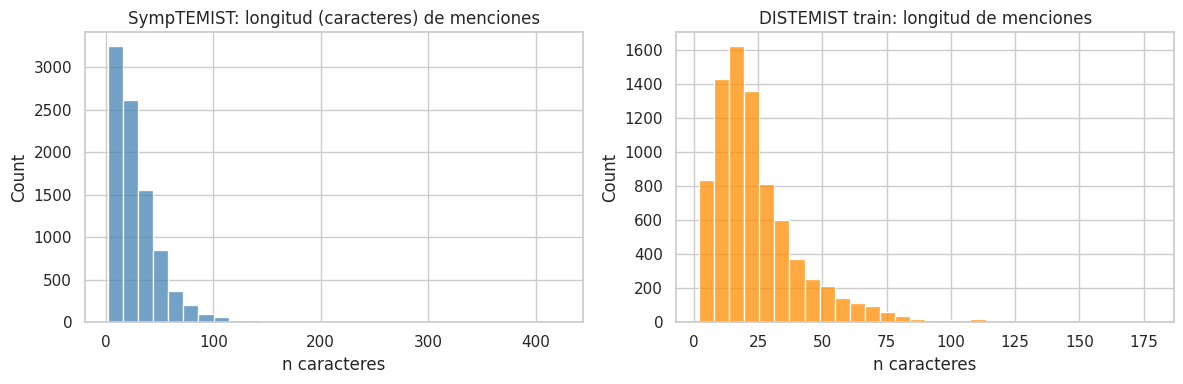

SympTEMIST - Top 15 menciones más frecuentes:
text
fiebre                 162
dolor                  122
asintomático            86
vómitos                 65
tumoración              65
astenia                 49
asintomática            45
proteinuria             45
masa                    45
afebril                 44
dolor abdominal         43
hematuria               40
buen estado general     36
cefalea                 34
sangrado                31

DISTEMIST train - Top 15 menciones más frecuentes:
text
lesión                      200
lesiones                     78
hipertensión arterial        69
tumor                        50
adenopatías                  43
fumador                      40
hematoma                     30
hta                          29
metástasis                   28
neoplasia                    28
anemia                       24
infección                    21
esplenomegalia               20
diabetes mellitus tipo 2     19
disfagia                     19


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SympTEMIST
sns.histplot((symp_ann['end_span'] - symp_ann['start_span']), bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("SympTEMIST: longitud (caracteres) de menciones")
axes[0].set_xlabel("n caracteres")
sns.histplot((dis_train_ann['end_span'] - dis_train_ann['start_span']), bins=30, ax=axes[1], color="darkorange")

# DISTEMIST
axes[1].set_title("DISTEMIST train: longitud de menciones")
axes[1].set_xlabel("n caracteres")
plt.tight_layout()
plt.show()


# Menciones mas frecuentes
print("SympTEMIST - Top 15 menciones más frecuentes:")
print(symp_ann['text'].str.lower().value_counts().head(15).to_string())
print("\nDISTEMIST train - Top 15 menciones más frecuentes:")
print(dis_train_ann['text'].str.lower().value_counts().head(15).to_string())

Los gráficos muestran la distribución de la longitud de las menciones en caracteres para SympTEMIST y DISTEMIST. Además, se listan las 15 menciones más frecuentes para cada dataset, revelando los síntomas y enfermedades más comunes en los conjuntos de datos. Vemos que, en ambos conjuntos, las entidades más frecuentes no tienen nombres largos y, de hecho, parecen ser solo palabras. Destacamos que el número de veces que se mencionen no importan, pues un Gazetteer, en principio, las almacenará independientemente de su número de aparición.

### 2.2 Partición de SympTEMIST y carga de textos

`load_texts`: Función auxiliar que toma una ruta a una carpeta y devuelve un diccionario cuyas claves son el nombre de los archivos sin TXT (aquí la actúan como IDs de los ejemplos) y el texto de los archivos.

In [ ]:
def load_texts(folder):
    return {fp.stem: fp.read_text(encoding="utf-8") for fp in folder.glob("*.txt")}

Vamos a hacer la partición. Para ello, como el formato de los datos se parecía un poco al de la práctica 1, hemos seguido un enfoque similar, pero se podría haber utilizado train_test_split de scikit-learn. Para este enfoque utilizamos un generador de números aleatorios, que es lo que Numpy recomienda.

In [ ]:
# Generador de numero aleatorios
rng = np.random.RandomState(SEED)
symp_files = sorted(symp_ann['filename'].unique())


# Barajado de ejemplos y seleccion
rng.shuffle(symp_files)
n_train = int(0.75 * len(symp_files))
symp_train_files = set(symp_files[:n_train])
symp_test_files  = set(symp_files[n_train:])
symp_train_ann = symp_ann[symp_ann['filename'].isin(symp_train_files)].reset_index(drop=True)
symp_test_ann  = symp_ann[symp_ann['filename'].isin(symp_test_files)].reset_index(drop=True)

# Carga de los diccionarios con los textos
symp_texts = load_texts(symp_txt_dir)
dis_train_texts = load_texts(dis_train_txt_dir)
dis_test_texts  = load_texts(dis_test_txt_dir)

# Algunas estadisticas
print(f"Numero total de anotaciones: {len(symp_train_ann)} / {len(symp_test_ann)}")
print(f"Conjunto train {len(symp_train_files)} docs")
print(f"Conjunto test {len(symp_test_files)} docs")
print(f"Cantidad de archivos de texto: TRAIN:{len(dis_train_texts)} / TEST:{len(dis_test_texts)}")

Numero total de anotaciones: 6709 / 2383
Conjunto train 558 docs
Conjunto test 186 docs
Cantidad de archivos de texto: TRAIN:750 / TEST:250


### 2.3 Construcción del extractor (gazetteer + PhraseMatcher + NegEx)

Vamos a crear la pipeline que propusimos en la segunda entrega. Para ello, hemos decidido que lo más cómodo será utilizar la librería SpaCy. La pipline es: Tokenización básica basada en palabras + lematización de las menciones del gazetteer + búsqueda por lema + filtro de solapamientos + ventana de negación.

In [ ]:
# Si es_core_news_md nunca ha sido descargado, ejecuta esta celda
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 19.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("es_core_news_md", disable=["ner", "textcat", "parser"])
if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")
print("Componentes del pipeline de spaCy", nlp.pipe_names)

Componentes del pipeline de spaCy ['tok2vec', 'morphologizer', 'attribute_ruler', 'lemmatizer', 'sentencizer']


A continuación se definen dos clases para el NER:

*   **`Mention`**: Una dataclass simple para almacenar la información de una mención detectada (texto, lema, posiciones de inicio y fin, y si está negada).
*   **`GazetteerNER`**: Esta clase implementa el extractor de entidades nombradas. Utiliza spaCy.PhraseMatcher para encontrar patrones en el texto basándose en lemas y aplica el filtro de negación para determinar si una mención debe ser descartada.

Las palabras que consideramos que niegan un término las definimos a mano, tomando las que creemos que son relevantes y pueden funcionar.

In [ ]:
# Palabras que niegan
NEGATION_CUES = {
    "no", "sin", "tampoco", "ningún", "ninguna", "ningun",
    "ausencia", "ausente", "descarta", "descartado", "descartada",
    "niega", "negativo", "negativa", "nunca", "jamás", "exenta", "exento",
}

# Implementacion del Gazetteer y su componente de mencion
@dataclass
class Mention:
    text: str
    lemma: str
    start_char: int
    end_char: int
    is_negated: bool

class GazetteerNER:
    def __init__(self, nlp, label: str, negation_window=4):
        # La pipeline
        self.nlp = nlp

        # Nombre de las entidades
        self.label = label

        # Ventana para la negacion
        self.negation_window = negation_window

        # Herramienta de SpaCy para detectar las entidades tras lematizacion
        self.matcher = PhraseMatcher(nlp.vocab, attr="LEMMA")

        # Numero de entidades en el diccionario
        self._n_patterns = 0


    def fit(self, mentions):
        # Elimina espacios, pasa a minusculas, quita duplicados
        unique = {m.strip().lower() for m in mentions if isinstance(m, str) and m.strip()}

        # Procesa los terminos en batches de 256
        patterns = [p for p in self.nlp.pipe(unique, batch_size=256) if len(p) > 0]

        # Registra entidades
        self.matcher.add(self.label, patterns)

        # Cuenta entidades
        self._n_patterns = len(patterns)

        # Devuelve el Gazetteer con las entidades
        return self


    def _is_negated(self, doc, span_start_token):
        # La ventana debe ser mayor que 0
        if self.negation_window <= 0:
            return False

        # Indice del token para el que empieza la busqueda hacia atras
        win_start = max(0, span_start_token - self.negation_window)

        # Comprueba si hay tokens que precedan dentro de la ventana y esten en nuestra lista de palabras negativas
        return any(tok.lower_ in NEGATION_CUES for tok in doc[win_start:span_start_token])


    def extract(self, text, apply_negation_filter=False):
        # Aplica el pipeline de SpaCy
        doc = self.nlp(text)

        # Ejecuta el PhraseMatcher para encontrar los matches como (match_id, start_token, end_token)
        raw = self.matcher(doc)

        # Resuelve solapamientos
        spans = [Span(doc, s, e, label=self.label) for _, s, e in raw]
        spans = spacy.util.filter_spans(spans)

        # Lista donde guardaremos las entidades extraidas
        out = []
        for sp in spans:

            # Aplica el filtro de negacion
            negated = self._is_negated(doc, sp.start)
            if apply_negation_filter and negated:
                continue

            out.append(Mention(sp.text, sp.lemma_.lower(), sp.start_char, sp.end_char, negated))

        return out

Creamos los dos Gazetteer y vemos cuántos patrones hemos encontrado:

In [ ]:
# Creamos los Gazetteers
ner_sintomas    = GazetteerNER(nlp, label="SINTOMA").fit(symp_train_ann['text'].astype(str).tolist())
ner_enfermedades = GazetteerNER(nlp, label="ENFERMEDAD").fit(dis_train_ann['text'].astype(str).tolist())

# Patrones encontrados
print(f"Gazetteer SINTOMAS: {ner_sintomas._n_patterns} patrones únicos")
print(f"Gazetteer ENFERMEDADES: {ner_enfermedades._n_patterns} patrones únicos")

Gazetteer SINTOMAS: 4672 patrones únicos
Gazetteer ENFERMEDADES: 5278 patrones únicos


### 2.4 Evaluación span-level (precisión / recall / F1)

* **Strict**: predicción acierta si offsets coinciden exactamente con gold.
* **Overlap**: vale con solapamiento de ≥1 carácter.

Evaluación sin filtro de negación (los datasets anotan menciones aunque estén negadas).

`prf:` Función auxiliar para calcular la Precisión (P), Recall (R) y F1-score (F). Esto nos es más cómodo porque necesitamos una serie de pasos para contar positivos y negativos al estar en un dominio donde calcular estas medidas es algo más complejo. Lo haremos abajo utilizando esta función auxiliar.





In [ ]:
def prf(tp, fp, fn):

    # Precision
    p = tp/(tp+fp) if (tp+fp) else 0.0

    # Recall
    r = tp/(tp+fn) if (tp+fn) else 0.0

    # F1
    f = 2*p*r/(p+r) if (p+r) else 0.0

    return p, r, f

`evaluate_ner`: Función encargada de evaluar el rendimiento de NER.

In [ ]:
def evaluate_ner(extractor, texts, gold_df, apply_negation_filter=False):
    tp_s = fp_s = fn_s = 0
    tp_o = fp_o = fn_o = 0

    # Itera sobre cada documento
    for fname, text in texts.items():

        # Extrae entidades
        preds = extractor.extract(text, apply_negation_filter=apply_negation_filter)

        # Extrae las anotaciones que utilizamos como verdad de los datos (gold standard)
        gold = gold_df[gold_df['filename'] == fname]

        # Sacamos los spans de entidades extraidas y anotadas
        gold_spans = list(zip(gold['start_span'].astype(int), gold['end_span'].astype(int)))
        pred_spans = [(m.start_char, m.end_char) for m in preds]

        # Vamos a calcular las metricas estrictas
        # Para contar, vamos a utilizar sets de Python, que son muy rapidos
        gold_set, pred_set = set(gold_spans), set(pred_spans)
        tp_s += len(gold_set & pred_set) # Interseccion de conjuntos
        fp_s += len(pred_set - gold_set) # Diferencia de predichas que no estan en las anotaciones
        fn_s += len(gold_set - pred_set) # Diferencia de las que estan en las anotaciones que no estan predichas

        # Lista booleana para controlar que entidades reales ya han sido emparejadas con una prediccio
        # Evita que una sola entidad real valide multiples predicciones solapadas
        gold_used = [False] * len(gold_spans)

        # Contamos solapamientos
        for ps, pe in pred_spans:
            hit = False
            for i, (gs, ge) in enumerate(gold_spans):
                if not gold_used[i] and not (pe <= gs or ps >= ge):
                    gold_used[i] = True
                    hit = True
                    break
            if hit: tp_o += 1
            else:   fp_o += 1
        fn_o += gold_used.count(False)

    # Calculamos metricas
    ps, rs, fs = prf(tp_s, fp_s, fn_s)
    po, ro, fo = prf(tp_o, fp_o, fn_o)

    return {"strict_P": ps, "strict_R": rs, "strict_F1": fs,
            "overlap_P": po, "overlap_R": ro, "overlap_F1": fo,
            "tp_strict": tp_s, "fp_strict": fp_s, "fn_strict": fn_s}



Primero evaluamos nuestra baseline con un etiquetador nulo:

In [ ]:
class EmptyNER:
    def extract(self, text, apply_negation_filter=False):
        return []

null_tagger = EmptyNER()

# Evaluamos el etiquetador nulo
symp_test_texts_d = {f: symp_texts[f] for f in symp_test_files if f in symp_texts}
res_sint_null = evaluate_ner(null_tagger, symp_test_texts_d, symp_test_ann)
res_enf_null  = evaluate_ner(null_tagger, dis_test_texts,    dis_test_ann)

results_null = pd.DataFrame([
    {"tarea": "NULL SympTEMIST", **res_sint_null},
    {"tarea": "NULL DISTEMIST", **res_enf_null},
])

results_null

,tarea,strict_P,strict_R,strict_F1,overlap_P,overlap_R,overlap_F1,tp_strict,fp_strict,fn_strict
0,NULL SympTEMIST,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2383
1,NULL DISTEMIST,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2598


Por como está hecho el conjunto de datos, parece que todos los ejemplos tienen entidad, por lo que el etiquetador nulo es bastante ineficaz.

Evaluamos los Gazetteers y mostramos una tabla con los resultados:

In [ ]:
symp_test_texts_d = {f: symp_texts[f] for f in symp_test_files if f in symp_texts}

res_sint = evaluate_ner(ner_sintomas,    symp_test_texts_d, symp_test_ann, apply_negation_filter=False)
res_enf  = evaluate_ner(ner_enfermedades, dis_test_texts,    dis_test_ann,  apply_negation_filter=False)

results_t2 = pd.DataFrame([
    {"tarea": "T2 SympTEMIST", **res_sint},
    {"tarea": "T2 DISTEMIST", **res_enf},
])
results_t2

,tarea,strict_P,strict_R,strict_F1,overlap_P,overlap_R,overlap_F1,tp_strict,fp_strict,fn_strict
0,T2 SympTEMIST,0.500609,0.344943,0.408447,0.776492,0.535040,0.633540,822,820,1561
1,T2 DISTEMIST,0.203094,0.358737,0.259357,0.359338,0.634719,0.458884,932,3657,1666


Hacemos una gráfica con las comparativas de varias métricas para  síntomas y enfermedades:

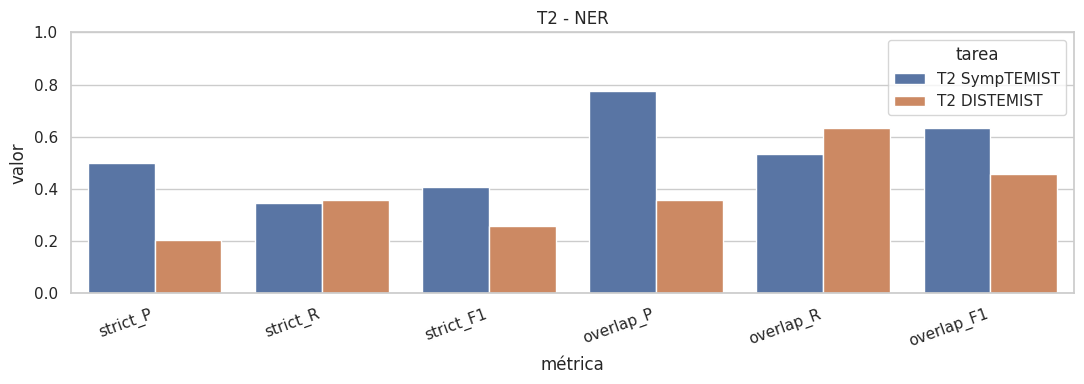

In [ ]:
plot_df = results_t2.melt(id_vars="tarea",
    value_vars=["strict_P","strict_R","strict_F1","overlap_P","overlap_R","overlap_F1"],
    var_name="métrica", value_name="valor")
plt.figure(figsize=(11, 4))
sns.barplot(data=plot_df, x="métrica", y="valor", hue="tarea")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("T2 - NER")
plt.tight_layout()
plt.show()

El grafico muestra las métricas de precisión, recall y F1-score para la evaluación de NER en síntomas y enfermedades. Se evalúan dos tipos de coincidencia: Strict (exacta) y Overlap (solapamiento).

Las métricas son más altas en la evaluación por solapamiento, indicando que el extractor es mejor detectando la presencia de menciones que su delimitación exacta. Parece haber mejor desempeño en los síntomas que las enfermedades.

### 2.5 Adición de los datos de validación a los Gazetteers

Una vez evaluados los modelos, para aumentar su eficacia en la PoC y no desperdiciar los datos de validación, añadimos también estos términos a los Gatteers:

In [ ]:
# Combinamos las menciones de entrenamiento y test para ampliar el diccionario
all_symp_mentions = pd.concat([symp_train_ann['text'], symp_test_ann['text']]).astype(str).tolist()
all_dis_mentions = pd.concat([dis_train_ann['text'], dis_test_ann['text']]).astype(str).tolist()

# Reentrenamos los Gazetteers con el conjunto completo
ner_sintomas = GazetteerNER(nlp, label="SINTOMA").fit(all_symp_mentions)
ner_enfermedades = GazetteerNER(nlp, label="ENFERMEDAD").fit(all_dis_mentions)

# Mostramos los nuevos conteos
print(f"Gazetteer SINTOMAS: {ner_sintomas._n_patterns} patrones únicos")
print(f"Gazetteer ENFERMEDADES: {ner_enfermedades._n_patterns} patrones únicos")

Gazetteer SINTOMAS: 6132 patrones únicos
Gazetteer ENFERMEDADES: 6738 patrones únicos


### 2.6 Demostración cualitativa del filtro de negación

Vamos a comprobar que el Gazetter funcione bien con el filtro de negación en unos pocos ejemplos:

In [ ]:
ejemplos = [
    "Llevo dos días con dolor abdominal y vómitos pero no fiebre ni cefalea.",
    "El paciente niega disnea aunque refiere tos seca y mareos.",
    "Refiere fuerte dolor de cabeza y punzadas en el pecho.",
    "Sin antecedentes de hipertensión ni diabetes, pero presenta obesidad y asma.",
]

# Visualizamos los ejemplos
for txt in ejemplos:
    print("Texto:", txt)
    sin_filtro = ner_sintomas.extract(txt, apply_negation_filter=False)
    con_filtro = ner_sintomas.extract(txt, apply_negation_filter=True)
    print("  detectados:", [(m.text, "NEG" if m.is_negated else "AFF") for m in sin_filtro])
    print("  tras filtro:", [m.text for m in con_filtro])
    print()

Texto: Llevo dos días con dolor abdominal y vómitos pero no fiebre ni cefalea.
  detectados: [('dolor abdominal', 'AFF'), ('vómitos', 'AFF'), ('cefalea', 'NEG')]
  tras filtro: ['dolor abdominal', 'vómitos']

Texto: El paciente niega disnea aunque refiere tos seca y mareos.
  detectados: [('disnea', 'NEG'), ('tos', 'NEG'), ('mareos', 'AFF')]
  tras filtro: ['mareos']

Texto: Refiere fuerte dolor de cabeza y punzadas en el pecho.
  detectados: [('dolor de cabeza', 'AFF')]
  tras filtro: ['dolor de cabeza']

Texto: Sin antecedentes de hipertensión ni diabetes, pero presenta obesidad y asma.
  detectados: []
  tras filtro: []



### 2.7 Guardado de los modelos

Guardamos las entidades encontradas en un TXT para poder volver a crear el Gazetteer de nuevo cuando sea conveniente. Guardamos también los resultados en CSV.

In [ ]:
t2_dir = MODELS_DIR / "t2_ner"
t2_dir.mkdir(exist_ok=True)
(t2_dir / "gazetteer_sintomas.txt").write_text(
    "\n".join(sorted({m.lower().strip() for m in symp_train_ann['text'].astype(str)})), encoding="utf-8")
(t2_dir / "gazetteer_enfermedades.txt").write_text(
    "\n".join(sorted({m.lower().strip() for m in dis_train_ann['text'].astype(str)})), encoding="utf-8")
results_t2.to_csv(t2_dir / "resultados_test.csv", index=False)

## 3. T3 - Diagnóstico probable (Symptom2Disease)

Symptom2Disease asocia 50 descripciones libres de síntomas (en inglés) a cada una de 24 patologías en 1200 muestras. Pasos:

1. **Traducción de inglés a español** con `Helsinki-NLP/opus-mt-en-es`

2. Limpieza y split estratificado 80/20

3. Fine-tuning de `PlanTL-GOB-ES/bsc-bio-ehr-es`.

4. Métricas: *accuracy* y *macro*-F1

### 3.1 Carga y EDA

Creamos la ruta de los datos y cargamos el CSV. Vamos a hacer conteo de clases:

In [ ]:
# Ruta
S2D_PATH = DATA_DIR / "clasificacion_sintomas" / "Symptom2Disease.csv"

# Carga de los datos
s2d = pd.read_csv(S2D_PATH)

# Vemos algunos ejemplos
s2d.head(3)

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...


Graficamos la distribución de las clases:

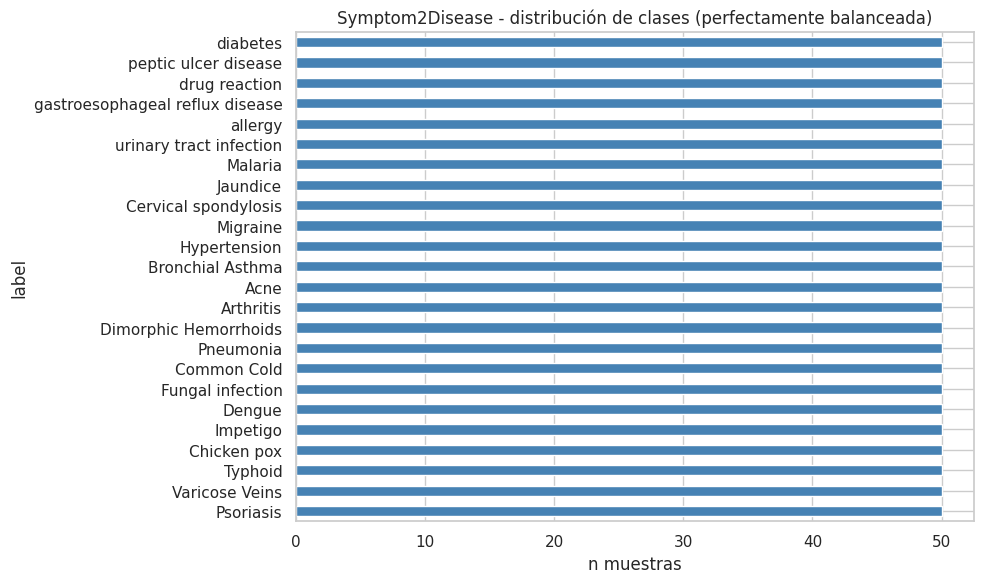

In [ ]:
plt.figure(figsize=(10, 6))
s2d['label'].value_counts().sort_values().plot(kind='barh', color="steelblue")
plt.title("Symptom2Disease - distribución de clases (perfectamente balanceada)")
plt.xlabel("n muestras")
plt.tight_layout()
plt.show()

Las 24 clases están perfectamente balanceadas, aunque no hay muchos ejemplos de cada una, solo 50.

Vemos algunas estadísticas de la longitud de las descripciones de los síntomas:

In [ ]:
s2d['len_words'] = s2d['text'].str.split().str.len()
print(f"Longitud (palabras): media={s2d['len_words'].mean()}, mediana={s2d['len_words'].median()}, max={s2d['len_words'].max()}")

Longitud (palabras): media=30.725, mediana=30.0, max=55


### 3.2 Traducción de inglés a español

Vamos a traducir las descripciones de los síntomas. Para hacerlo de forma automática pero sin usar API Keys o similar, usaremos un modelo local mediano especializado en traducir del inglés al español, que será Helsinki-NLP/opus-mt-en-es:

In [ ]:
# Ruta de la salida
S2D_DIR = DATA_DIR / "clasificacion_sintomas" / "symptom2disease_es.csv"

# Cargamos el modelo y su tokenizador
tok_es = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-es")
mdl_es = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-es").to(DEVICE).eval()

# Iteramos sobre los textos y los traducimos en batches de 16
texts = s2d['text'].astype(str).tolist()
out = []
for i in range(0, len(texts), 16):
    batch = texts[i:i+16]

    # Tokenizamos
    enc = tok_es(batch, return_tensors="pt", padding=True, truncation=True, max_length=256).to(DEVICE)

    # Generamos la traduccion
    with torch.no_grad():
        gen = mdl_es.generate(**enc, max_new_tokens=256, num_beams=2)

    # Actualizamos cada 5 batches
    out.extend(tok_es.batch_decode(gen, skip_special_tokens=True))
    if (i // 16) % 5 == 0:
        print(f"  {min(i+16, len(texts))}/{len(texts)}")

# Creamos el conjunto de datos en nuestro idioma
s2d_es = s2d.copy()
s2d_es['text_es'] = out
s2d_es.to_csv(S2D_DIR, index=False)

# Liberar memoria para no tener el modelo y su tokenizador en la CPU/GPU
del tok_es, mdl_es
torch.cuda.empty_cache() if torch.cuda.is_available() else None

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

  16/1200
  96/1200
  176/1200
  256/1200
  336/1200
  416/1200
  496/1200
  576/1200
  656/1200
  736/1200
  816/1200
  896/1200
  976/1200
  1056/1200
  1136/1200


### 3.3 Split estratificado 80/20 y codificación de etiquetas

Al no haber muchos datos (sobre todo teniendo en cuenta que tenemos 24 clases), reservamos bastante para el entrenamiento (80%) aunque eso signifique tenemos menos para validación.

In [ ]:
# Codificamos las etiquetas
labels_t3 = sorted(s2d_es['label'].unique())
label2id_t3 = {l: i for i, l in enumerate(labels_t3)}
id2label_t3 = {i: l for l, i in label2id_t3.items()}
s2d_es['label_id'] = s2d_es['label'].map(label2id_t3)

# Hacemos la division en entrenamiento y validacion
X = s2d_es['text_es'].astype(str).values
y = s2d_es['label_id'].values
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"Train/Val = {len(X_tr)}/{len(X_val)}  -  {len(labels_t3)} clases")

Train/Val = 960/240  -  24 clases


### 3.4 Fine-tuning de `bsc-bio-ehr-es`

Vamos a fine-tunear el modelo para clasificación de síntomas. Definimos unas funciones auxiliares específicas:

`make_ds`: Función para convertir un conjunto de datos (textos y etiquetas) en un objeto Dataset de la libreria datasets. Necesario para la libreria transformers.

In [ ]:
def make_ds(X, y):
    return Dataset.from_dict({"text": list(X), "label": [int(v) for v in y]})

`tok_fn`: Función para tokenizar un lote de textos de entrada con el tokenizador de esta tarea:

In [ ]:
def tok_fn(batch):
  return tok_t3(batch["text"], truncation=True, max_length=MAX_LEN_T3)

Cargamos el modelo y su tokenizador, además de convertir a Dataset nuestros conjuntos de datos:

In [ ]:
# Nombre del modelo
T3_MODEL_NAME = "PlanTL-GOB-ES/bsc-bio-ehr-es"

# Ruta de guardado
T3_OUT = MODELS_DIR / "t3_diagnostico"
T3_OUT.mkdir(exist_ok=True) # Creamos el fichero por si acaso

# Tokenizador
tok_t3 = AutoTokenizer.from_pretrained(T3_MODEL_NAME)

# Hacemos Dataset los DataFrames
ds_tr  = make_ds(X_tr,  y_tr)
ds_val = make_ds(X_val, y_val)

# Se tomaran 192 tokens como maximo al tokenizar
MAX_LEN_T3 = 192
ds_tr  = ds_tr.map(tok_fn,  batched=True)
ds_val = ds_val.map(tok_fn, batched=True)

# Cargamos las metricas para el callback
acc_metric = hf_evaluate.load("accuracy")
f1_metric  = hf_evaluate.load("f1")

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/521k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Map:   0%|          | 0/960 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

`compute_metrics`: Función para calcular metricas de evaluación como la precisión (accuracy) y el F1-score macro a partir de las predicciones del modelo. La usaremos como callback en el fine-tuning.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1":  f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

Construimos el modelo, el entrenador y comenzamos el entrenamiento. Seleccionamos un LR bajo para el fine-tuning. Cronometramos para hacernos una idea de cuánto tarda.

In [ ]:
# Modelo
model_t3 = AutoModelForSequenceClassification.from_pretrained(
    T3_MODEL_NAME, num_labels=len(labels_t3),
    id2label=id2label_t3, label2id=label2id_t3,
)

# Argumentos para el entrenamiento
args_t3 = TrainingArguments(
    output_dir=str(T3_OUT / "_trainer"),
    num_train_epochs=15,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1", # Nos quedamos con el mejor modelo segun F1-Macro
    logging_steps=25,
    seed=SEED,
    report_to=[],
    fp16=False,
)

# A los batches le aplicamos padding
collator = DataCollatorWithPadding(tok_t3)

# Entrenador del modelo
trainer_t3 = Trainer(
    model=model_t3, args=args_t3,
    train_dataset=ds_tr, eval_dataset=ds_val,
    processing_class=tok_t3,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

# Contamos el tiempo
t0 = time.time()
trainer_t3.train()
print(f"Tiempo de entrenamiento T3: {time.time()-t0:.1f}s")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: PlanTL-GOB-ES/bsc-bio-ehr-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed i

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,3.113457,2.895396,0.366667,0.305676
2,1.955450,1.469008,0.858333,0.851088
3,0.957528,0.707629,0.937500,0.933421
4,0.443171,0.409189,0.929167,0.924398
5,0.191106,0.230660,0.966667,0.965820
6,0.104421,0.157526,0.970833,0.970572
7,0.056183,0.152605,0.966667,0.965863
8,0.038644,0.129077,0.970833,0.970329
9,0.031344,0.125998,0.970833,0.970329
10,0.025503,0.124875,0.970833,0.970329


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Tiempo de entrenamiento T3: 773.6s


### 3.5 Evaluación y análisis de errores en validación

En primer lugar, vamos a calcular distintas métricas sobre el conjunto de validación:

In [ ]:
# Predecimos probabilidades
pred_out = trainer_t3.predict(ds_val)

# Nos quedamos con la clase predicha
y_pred_t3 = np.argmax(pred_out.predictions, axis=-1)

# Sacamos estadisticas
print(classification_report(y_val, y_pred_t3, target_names=labels_t3, digits=3))

                                 precision    recall  f1-score   support

                           Acne      1.000     1.000     1.000        10
                      Arthritis      0.909     1.000     0.952        10
               Bronchial Asthma      1.000     1.000     1.000        10
           Cervical spondylosis      1.000     1.000     1.000        10
                    Chicken pox      0.900     0.900     0.900        10
                    Common Cold      1.000     1.000     1.000        10
                         Dengue      1.000     0.900     0.947        10
          Dimorphic Hemorrhoids      1.000     1.000     1.000        10
               Fungal infection      1.000     1.000     1.000        10
                   Hypertension      1.000     1.000     1.000        10
                       Impetigo      1.000     1.000     1.000        10
                       Jaundice      1.000     1.000     1.000        10
                        Malaria      1.000     1.0

Los resultados son muy buenos, tanto dentro de las clases como globalmente. Bajan algo en Chicken pox, diabetes y drug reaction, pero siguen siendo buenas cifras.

Representamos la matriz de confusión como un mapa de calor:

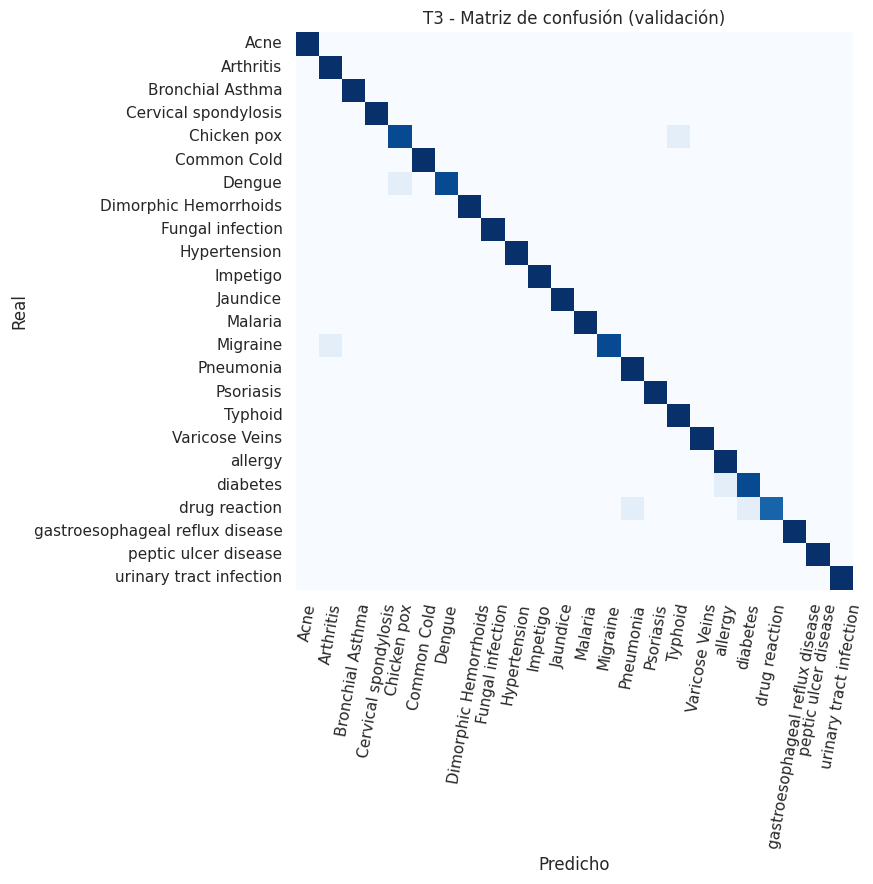

In [ ]:
cm = confusion_matrix(y_val, y_pred_t3)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, xticklabels=labels_t3, yticklabels=labels_t3, cmap="Blues", cbar=False, square=True)
plt.xticks(rotation=80)
plt.yticks(rotation=0)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("T3 - Matriz de confusión (validación)")
plt.tight_layout()
plt.show()

Al ser los resultados tan buenos, en la matriz de confusión no se observan prácticamente errores. Exploramos la confusión con Chicken pox, diabetes y drug reaction, ya que son las categorías con peor F1-Macro y examinamos con qué otra enfermedad se confunden:

In [ ]:
clases_interes = ['Chicken pox', 'diabetes', 'drug reaction']

df_resultados = pd.DataFrame({
    'texto': X_val,
    'real': [id2label_t3[i] for i in y_val],
    'predicho': [id2label_t3[i] for i in y_pred_t3]
})

df_fallos = df_resultados[df_resultados['real'] != df_resultados['predicho']]

# Falsos negativos
print("= FALSOS NEGATIVOS")
fn_casos = df_fallos[df_fallos['real'].isin(clases_interes)]
for idx, row in fn_casos.iterrows():
    print(f"ID: {idx}")
    print(f"Texto: {row['texto']}")
    print(f"REAL: {row['real']} | PREDICCIÓN: {row['predicho']}")
    print("-" * 80)

print("\n" * 3)

# Falsos positivos
print("= FALSOS POSITIVOS")
fp_casos = df_fallos[df_fallos['predicho'].isin(clases_interes)]
for idx, row in fp_casos.iterrows():
    print(f"ID: {idx}")
    print(f"Texto: {row['texto']}")
    print(f"REAL: {row['real']} | PREDICCIÓN: {row['predicho']}")
    print("-" * 80)

= FALSOS NEGATIVOS
ID: 111
Texto: Constantemente estornudo y tengo tos seca. Mis infecciones no parecen estar sanando, y tengo palpitaciones. Mi garganta sufre ocasionalmente, pero generalmente mejora.
REAL: diabetes | PREDICCIÓN: allergy
--------------------------------------------------------------------------------
ID: 145
Texto: Tengo fiebre y me siento muy mareado y mareado. Mi corazón late muy rápido y me siento muy confundido. No soy capaz de pensar muy claro y todo se siente muy nublado
REAL: drug reaction | PREDICCIÓN: Pneumonia
--------------------------------------------------------------------------------
ID: 155
Texto: Tengo un sabor metálico en la boca, y también tengo una sensación de cambio de gusto y olfato. A veces tengo dolor articular muy insoportable y dolor muscular
REAL: drug reaction | PREDICCIÓN: diabetes
--------------------------------------------------------------------------------
ID: 220
Texto: He tenido una fiebre leve en los últimos días, y está empezand

Aunque un análisis más profundo requeriría conocimientos médicos, sí parece que se confunden enfermedades muy diferentes entre sí.

### 3.6 Salvamos el modelo

Guardamos modelo, tokenizador y configuración:

In [ ]:
trainer_t3.save_model(str(T3_OUT))
tok_t3.save_pretrained(str(T3_OUT))
with open(T3_OUT / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id_t3, "id2label": id2label_t3}, f, ensure_ascii=False, indent=2)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 4. T4 - Clasificación de gravedad (triaje)

Combinamos:
* `medical_data.json` con 920 muestras turcas con `urgency_level` en {1,2,3,4,5} y texto en turco que traducimos con Helsinki-NLP/opus-mt-tc-big-tr-es.
* `triaje_chatgpt.csv`, `triaje_gemini.csv`, `triaje_claude.csv` - 3000 muestras LLM en español, niveles 1-5.
* `triaje_ood.csv` - 2000 muestras *out-of-domain* con etiqueta 0.

En total tenemos unos 5920 ejemplos con seis clases: 0, 1, 2, 3, 4, 5.

Compararemos dos enfoques:
* **Baseline (A)**: TF-IDF + Regresión logística.
* **Sistema (B)**: Fine-tuning de bsc-bio-ehr-es.


### 4.1 Carga, traducción del JSON turco y consolidación

Creamos la ruta de los datos y cargamos el CSV. Traducimos las descripciones de los pacientes. Para hacerlo de forma automática pero sin usar API Keys o similar, usaremos un modelo local mediano especializado en traducir del inglés al español, que será Helsinki-NLP/opus-mt-en-es:

In [11]:
# Definimos rutas para el dataset turco
TRIAJE_TK_PATH = DATA_DIR / "triaje" / "medical_data.json"
TRIAJE_ES_PATH = DATA_DIR / "triaje" / "medical_data_es.csv"

with open(TRIAJE_TK_PATH, "r", encoding="utf-8") as f:
    med_data = json.load(f)

# Cargamos tokenizador y modelo de traduccion TR-ES
tok_tr = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-tr-es")
mdl_tr = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-tr-es").to(DEVICE).eval()

texts = [d["input_text"] for d in med_data]

out = []
# Traducimos por batches
for i in range(0, len(texts), 16):
    batch = texts[i:i+16]
    enc = tok_tr(batch, return_tensors="pt", padding=True, truncation=True, max_length=256).to(DEVICE)
    with torch.no_grad():
        gen = mdl_tr.generate(**enc, max_new_tokens=256, num_beams=2)
    out.extend(tok_tr.batch_decode(gen, skip_special_tokens=True))
    if (i // 16) % 5 == 0:
        print(f"  {min(i+16, len(texts))}/{len(texts)}")

# Guardamos el resultado en CSV
es_texts = out
med_es = pd.DataFrame({
    "texto":    es_texts,
    "urgencia": [d["urgency_level"] for d in med_data],
})
med_es.to_csv(TRIAJE_ES_PATH, index=False)

# Liberamos memoria
del tok_tr, mdl_tr
if torch.cuda.is_available():
    torch.cuda.empty_cache()

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/840k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/816k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

  16/920
  96/920
  176/920
  256/920
  336/920
  416/920
  496/920
  576/920
  656/920
  736/920
  816/920
  896/920


Vamos a cargar los CSV de los datasets sinténticos, así como del conjunto de datos traducido. Para ellos, nos servimos de la siguiente función auxiliar.

`load_csv`: Función que carga un archivo CSV y devuelve un DataFrame

In [12]:
def load_csv(p):
  return pd.read_csv(p)[['texto','urgencia']]

Cargamos y consolidamos los datos:

In [13]:
# Consolidamos fuentes de datos de triaje
TRIAJE_DIR = DATA_DIR / "triaje"

df_chat   = load_csv(TRIAJE_DIR / "triaje_chatgpt.csv")
df_gem    = load_csv(TRIAJE_DIR / "triaje_gemini.csv")
df_claude = load_csv(TRIAJE_DIR / "triaje_claude.csv")
df_ood    = load_csv(TRIAJE_DIR / "triaje_ood.csv")

# Asignamos etiquetas de fuente
med_es['fuente']    = "turkish_mt"
df_chat['fuente']   = "chatgpt"
df_gem['fuente']    = "gemini"
df_claude['fuente'] = "claude"
df_ood['fuente']    = "ood"

# Concatenamos y limpiamos
triaje = pd.concat([med_es, df_chat, df_gem, df_claude, df_ood], ignore_index=True)
triaje = triaje.dropna(subset=['texto','urgencia']).reset_index(drop=True)
triaje['urgencia'] = triaje['urgencia'].astype(int)

print(f"Total: {len(triaje)}")
print(triaje.groupby(['fuente','urgencia']).size().unstack(fill_value=0))

Total: 5920
urgencia       0    1    2    3    4    5
fuente                                   
chatgpt        0  200  200  200  200  200
claude         0  200  200  200  200  200
gemini         0  200  200  200  200  200
ood         2000    0    0    0    0    0
turkish_mt     0   62  266  254  170  168


Hacemos conteo de las clases y extraemos algunas características.

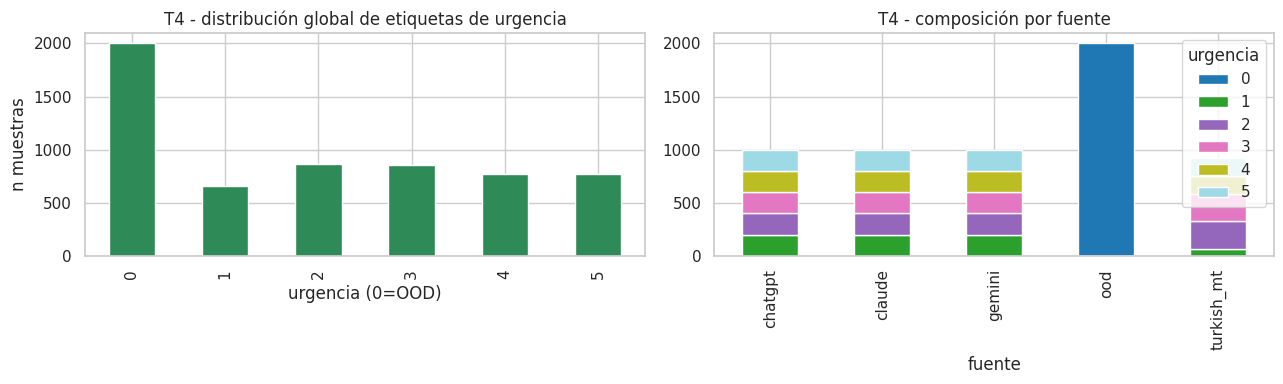

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
triaje['urgencia'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color="seagreen")
axes[0].set_title("T4 - distribución global de etiquetas de urgencia")
axes[0].set_xlabel("urgencia (0=OOD)")
axes[0].set_ylabel("n muestras")

triaje.groupby(['fuente','urgencia']).size().unstack(fill_value=0).plot(
    kind='bar', stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("T4 - composición por fuente")
axes[1].set_xlabel("fuente")
plt.tight_layout()
plt.show()

Vemos que hay desbalanceo hacia OOD, lo cual es intencional. Pensamos que esta clase requeriría más ejemplos y más variados, al poder tratarse, en la páctica, de cualquier cosa salvo la descripción de una dolencia. Por lo demás, al añadir los ejemplos de los LLMs sí hay mayor balanceo en las clases, aunque en el conjunto de datos turco el desbalanceo era muy grande (habiendo muy pocos casos de la clase 1).

Extraemos algunas estadísticas:

In [15]:
triaje['len_words'] = triaje['texto'].astype(str).str.split().str.len()
print("Longitud (palabras) por urgencia:")
print(triaje.groupby('urgencia')['len_words'].describe()[['count','mean','50%','max']])

Longitud (palabras) por urgencia:
           count        mean    50%    max
urgencia                                  
0         2000.0  111.651500  134.0  143.0
1          662.0  138.036254  139.5  198.0
2          866.0  105.602771  133.0  198.0
3          854.0  106.949649  136.0  198.0
4          770.0  118.605195  137.0  198.0
5          768.0  118.782552  137.0  198.0


La media de longitud en palabras de unas 135, variando un poco según la clase. Las descripciones OOD son significativamente más cortas y homogéneas, con la media cerca de la mediana y cerca del máximo.

### 4.2 Split estratificado 80/10/10

Dividimos de forma estratificada en entrenamiento (80%), validación (10%) y test(10%). Con este último subconjunto mediremos el rendimiento del modelo que pretendemos utilizar para el sistema, el basado en RoBERTa.

In [16]:
X = triaje['texto'].astype(str).values
y = triaje['urgencia'].astype(int).values

X_tr4, X_tmp, y_tr4, y_tmp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_val4, X_te4, y_val4, y_te4 = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"Train/Val/Test = {len(X_tr4)}/{len(X_val4)}/{len(X_te4)}")

Train/Val/Test = 4736/592/592


### 4.3 Baseline TF-IDF + Regresión logística

Entrenamos nuestra baseline. Esta, recordemos, consiste en aplicar TF-IDF y regresión logística. Para TF-IDF lo hacemos con eliminamos tildes y pasamos a minúscula, de forma que paliamos un poco la dispersión de los datos.

In [20]:
# Pipeline de Baseline con TF-IDF y regresion logistica
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(strip_accents="unicode", lowercase=True)),
    ("lr", LogisticRegression(max_iter=2000))
])

# Entrenamiento de la baseline
t0 = time.time()
baseline.fit(X_tr4, y_tr4)
print(f"Tiempo entrenamiento baseline: {time.time()-t0}s")

Tiempo entrenamiento baseline: 8.3998441696167s


In [22]:
# Prediccion en validacion
y_pred_base = baseline.predict(X_val4)
print(classification_report(y_val4, y_pred_base, digits=3))

              precision    recall  f1-score   support

           0      0.985     0.995     0.990       200
           1      1.000     0.894     0.944        66
           2      0.760     0.884     0.817        86
           3      0.828     0.837     0.832        86
           4      0.910     0.792     0.847        77
           5      0.935     0.935     0.935        77

    accuracy                          0.910       592
   macro avg      0.903     0.890     0.894       592
weighted avg      0.915     0.910     0.911       592



Los resultados son, en egeneral buenos, desmejorando en las clases intermedias (2, 3 y 4), pero siendo aún así bastante prometedores. Esto hace que la F1-Macro se desplome un poco hasta caer por debajo del 0.9.

Guardamos nuestra baseline:

In [ ]:
T4_OUT = MODELS_DIR / "t4_triaje"
T4_OUT.mkdir(exist_ok=True)
_ = joblib.dump(baseline, T4_OUT / "baseline_tfidf_logreg.joblib")


### 4.4 Sistema - fine-tuning de `bsc-bio-ehr-es`

Vamos a hacer fine-tuning al modelo para el triaje. Definimos unas funciones auxiliares específicas:

`encode_y`: Función que convierte una serie de etiquetas de urgencia (valores originales) en sus correspondientes IDs numéricos definidos en label2id_t4 y los devuelve como un array de NumPy.

In [23]:
def encode_y(y_arr):
  return np.array([label2id_t4[int(v)] for v in y_arr])


`tok_fn_t4`: Función que tokeniza un lote de textos de entrada utilizando el tokenizador tok_t4 y aplica truncamiento si los textos exceden la longitud máxima (MAX_LEN_T4).

In [24]:
def tok_fn_t4(batch):
  return tok_t4(batch["text"], truncation=True, max_length=MAX_LEN_T4)


Cargamos el modelo y su tokenizador, además de convertir a Dataset nuestros conjuntos de datos:

In [25]:
# Nombre del modelo
T4_MODEL_NAME = "PlanTL-GOB-ES/bsc-bio-ehr-es"

# Tokenizador
tok_t4 = AutoTokenizer.from_pretrained(T4_MODEL_NAME)

# Codificamos las etiquetas
labels_t4 = sorted(np.unique(y).tolist())  # [0,1,2,3,4,5]
label2id_t4 = {int(l): i for i, l in enumerate(labels_t4)}
id2label_t4 = {i: int(l) for l, i in label2id_t4.items()}

# Convertimos los DataFrames a Dataset
ds_tr_t4  = Dataset.from_dict({"text": list(X_tr4),  "label": encode_y(y_tr4).tolist()})
ds_val_t4 = Dataset.from_dict({"text": list(X_val4), "label": encode_y(y_val4).tolist()})
ds_te_t4  = Dataset.from_dict({"text": list(X_te4),  "label": encode_y(y_te4).tolist()})

# Se toman 256 tokens como maximo al tokenizar
MAX_LEN_T4 = 256
ds_tr_t4  = ds_tr_t4.map(tok_fn_t4,  batched=True)
ds_val_t4 = ds_val_t4.map(tok_fn_t4, batched=True)
ds_te_t4  = ds_te_t4.map(tok_fn_t4,  batched=True)

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/521k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Map:   0%|          | 0/4736 [00:00<?, ? examples/s]

Map:   0%|          | 0/592 [00:00<?, ? examples/s]

Map:   0%|          | 0/592 [00:00<?, ? examples/s]

Construimos el modelo, el entrenador y comenzamos el entrenamiento. Seleccionamos un LR bajo para el fine-tuning. Cronometramos para hacernos una idea de cuánto tarda.

In [ ]:
# Cargamos modelo preentrenado para clasificacion T4
model_t4 = AutoModelForSequenceClassification.from_pretrained(
    T4_MODEL_NAME, num_labels=len(labels_t4),
    id2label={i: str(l) for i,l in id2label_t4.items()},
    label2id={str(k): v for k,v in label2id_t4.items()},
)

# Configuramos argumentos de entrenamiento
args_t4 = TrainingArguments(
    output_dir=str(T4_OUT / "_trainer"),
    num_train_epochs=15,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    seed=SEED,
    report_to=[],
    fp16=False,
)

# Inicializamos el entrenador del sistema
trainer_t4 = Trainer(
    model=model_t4, args=args_t4,
    train_dataset=ds_tr_t4, eval_dataset=ds_val_t4,
    processing_class=tok_t4, data_collator=DataCollatorWithPadding(tok_t4),
    compute_metrics=compute_metrics,
)

# Ejecutamos fine-tuning
t0 = time.time()
trainer_t4.train()
print(f"Tiempo de entrenamiento T4: {time.time()-t0:.1f}s")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: PlanTL-GOB-ES/bsc-bio-ehr-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed i

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.584105,0.471422,0.800676,0.762417
2,0.269191,0.222452,0.905405,0.889552
3,0.194684,0.204491,0.918919,0.901818
4,0.128667,0.315731,0.918919,0.900945
5,0.103643,0.409166,0.922297,0.905123
6,0.079698,0.404711,0.923986,0.907929
7,0.036122,0.468626,0.925676,0.909120
8,0.048464,0.517340,0.925676,0.909576
9,0.005309,0.556812,0.922297,0.907212
10,0.021586,0.590221,0.925676,0.910013


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Tiempo de entrenamiento T4 (fine-tuning): 1442.0s


### 4.5 Evaluación final y comparación

Comparamos el modelo basado en RoBERTa y la baseline en validación:

In [30]:
# Predicciones finales del sistema en validacion
pred_out_t4 = trainer_t4.predict(ds_val_t4)
y_pred_t4_enc = np.argmax(pred_out_t4.predictions, axis=-1)
y_pred_t4 = np.array([id2label_t4[int(i)] for i in y_pred_t4_enc])

# Reporte de metricas en validacion
print(classification_report(y_val4, y_pred_t4, digits=3))

              precision    recall  f1-score   support

           0      1.000     0.995     0.997       200
           1      0.969     0.939     0.954        66
           2      0.815     0.872     0.843        86
           3      0.872     0.872     0.872        86
           4      0.878     0.844     0.861        77
           5      0.974     0.974     0.974        77

    accuracy                          0.931       592
   macro avg      0.918     0.916     0.917       592
weighted avg      0.932     0.931     0.931       592



Hemos conseguido mejorar los resultados de la F1-Macro. Muy importante es también que mantenemos o mejoramos la Recall, que en un caso de uso como este también es muy importante, sobre todo en la clase 1, la de mayor gravedad.

A continuación, comparamos las métricas generales (Accuracy y Macro F1) entre la baseline y el sistema basado en RoBERTa utilizando el conjunto de validación.


,modelo,accuracy,macro_f1
0,Baseline TF-IDF + RL,0.910473,0.894319
1,Sistema RoBERTa,0.930743,0.916847


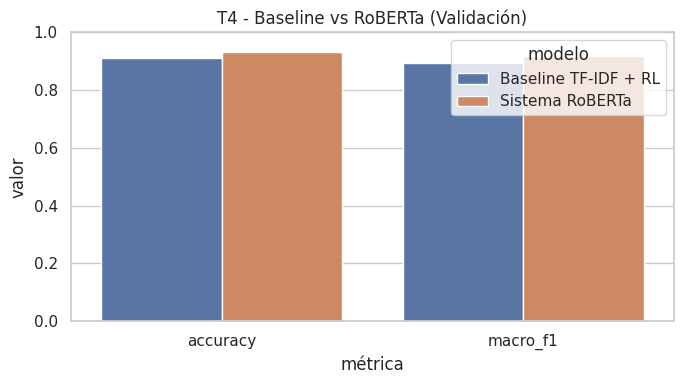

In [31]:
# Prediccion de la baseline en validacion para la comparativa
y_pred_base_val = baseline.predict(X_val4)

# Comparativa
comp = pd.DataFrame([
    {"modelo": "Baseline TF-IDF + RL",
     "accuracy": accuracy_score(y_val4, y_pred_base_val),
     "macro_f1": f1_score(y_val4, y_pred_base_val, average='macro')},
    {"modelo": "Sistema RoBERTa",
     "accuracy": accuracy_score(y_val4, y_pred_t4),
     "macro_f1": f1_score(y_val4, y_pred_t4, average='macro')},
])
display(comp)

plt.figure(figsize=(7,4))
comp.melt(id_vars="modelo", var_name="métrica", value_name="valor").pipe(
    lambda d: sns.barplot(data=d, x="métrica", y="valor", hue="modelo"))
plt.ylim(0, 1)
plt.title("T4 - Baseline vs RoBERTa (Validación)")
plt.tight_layout()
plt.show()

El modelo basado en RoBERTa gana en accuracy y F1-Macro a la baseline, aunque sa por poco.

In [32]:
# Analisis de under-triage en validacion
def triage_safety(y_true, y_pred):
    under_triage = sum(1 for r, p in zip(y_true, y_pred) if p > r and r != 0)
    total_clinical = sum(1 for r in y_true if r != 0)
    return under_triage / total_clinical if total_clinical > 0 else 0

print("Baseline (Val) :", triage_safety(y_val4, y_pred_base_val))
print("RoBERTa  (Val) :", triage_safety(y_val4, y_pred_t4))

Baseline (Val) : 0.05612244897959184
RoBERTa  (Val) : 0.05102040816326531


El nivel de under triaje es menor en el modelo basado en RoBERTa, lo cual significa que, para este propósito, mejor. Esta métrica es más ilustrativa que la Recall, ya que lo más importante, sobre todo cuando hay vidas en juego, es no subestimar la importancia de un caso. Por eso, incluso aunque el modelo que vamos a emplear en el sistema suponga una ganacia modesta, sigue siendo un logro importante.


### 4.5.1 Analisis detallado por categoria

Calculamos la precision por cada nivel de urgencia para comparar ambos enfoques visualmente y analizamos los errores criticos.

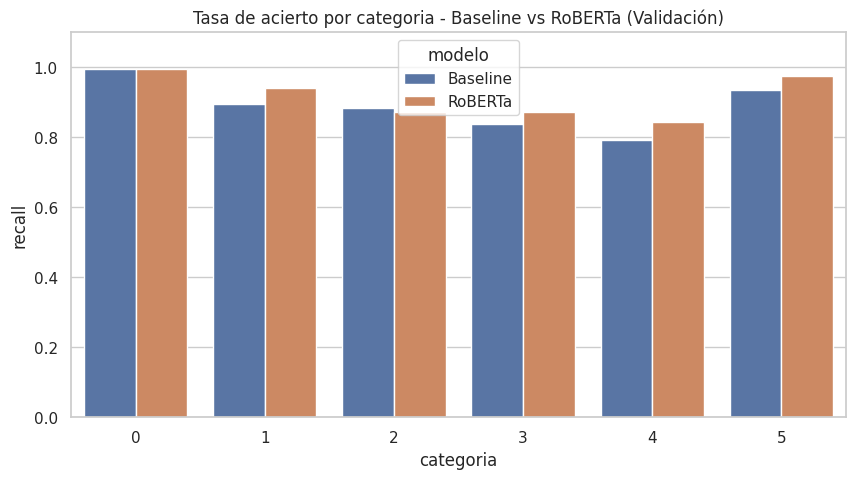

In [33]:
# Calculo de acierto por clase para Baseline y Sistema en validacion
report_base = classification_report(y_val4, y_pred_base_val, output_dict=True)
report_t4   = classification_report(y_val4, y_pred_t4, output_dict=True)

acc_per_class = []
for l in labels_t4:
    acc_per_class.append({"categoria": str(l), "modelo": "Baseline", "recall": report_base[str(l)]["recall"]})
    acc_per_class.append({"categoria": str(l), "modelo": "RoBERTa",  "recall": report_t4[str(l)]["recall"]})

df_acc = pd.DataFrame(acc_per_class)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_acc, x="categoria", y="recall", hue="modelo")
plt.title("Tasa de acierto por categoria - Baseline vs RoBERTa (Validación)")
plt.ylim(0, 1.1)
plt.show()

La Recall por categoría es igual o mejor en el modelo del sistema, como ya habíamos visto antes en la tabla. Esto confirma es coherente con los resultados de under-triaje también (aunque no necesariamente tendría por qué ser así). De nuevo, incluso aunque suponga una ganacia modesta sobre la baseline, sigue siendo un logro importante.

Visualizamos las matrices de confusión para observar los patrones de error y las confusiones entre niveles de urgencia adyacentes.

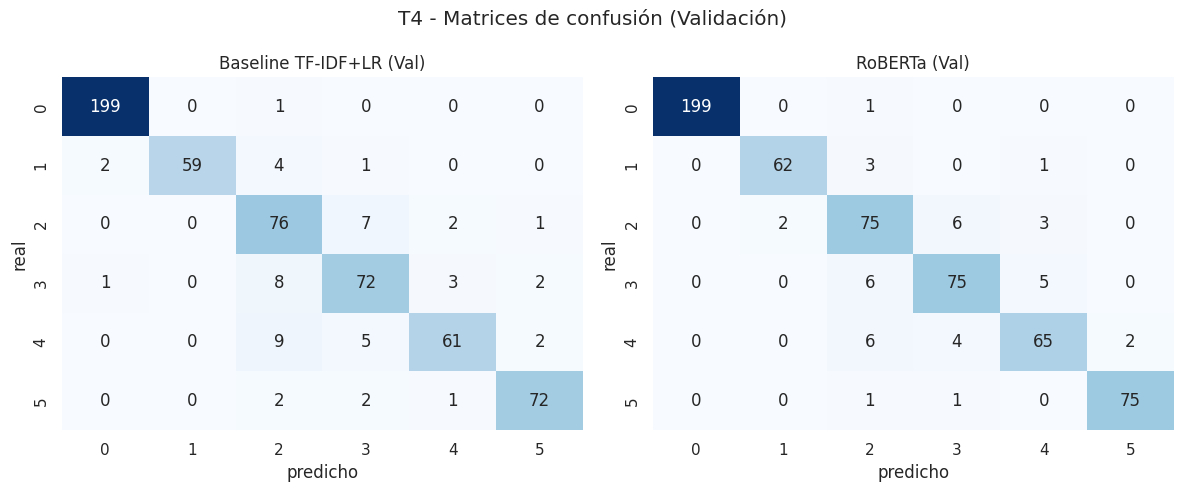

In [ ]:
# Matrices de confusion en validacion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in [(axes[0], y_pred_base_val, "Baseline TF-IDF+LR (Val)"),
                           (axes[1], y_pred_t4,   "RoBERTa (Val)")]:
    cm = confusion_matrix(y_val4, y_pred, labels=labels_t4)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_t4, yticklabels=labels_t4, ax=ax, cbar=False)
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(title)
plt.suptitle("T4 - Matrices de confusión (Validación)")
plt.tight_layout()
plt.show()

Vemos que sobre todo se confunden entre sí las clases centrales en ambos modelos, solo teniendo un fallo realmente grave el modelo basado en RoBERTa para la clase 1, que confundió con la 4 (de poca gravedad). Sí es preocupante, para este modelo, que confunda casos de gravedad 2 (que sigue siendo alta) con casos de gravedad 3 o 4, aunque para la baseline se observa un comportamiento similar.

Identificamos cuáles son los errores más comunes cometidos por ambos modelos en el set de validación.


In [ ]:
def top_confusions(y_true, y_pred, n=5):
    """Devuelve los n pares de (Real, Predicho) más comunes que son erróneos como enteros."""
    errors = [(int(r), int(p)) for r, p in zip(y_true, y_pred) if r != p]
    return Counter(errors).most_common(n)

# Pares de confusion mas comunes en validacion
print("Top confusiones Baseline (Val):")
print(top_confusions(y_val4, y_pred_base_val))
print("\nTop confusiones RoBERTa (Val):")
print(top_confusions(y_val4, y_pred_t4))

Top confusiones Baseline (Val):
[((4, 2), 9), ((3, 2), 8), ((2, 3), 7), ((4, 3), 5), ((1, 2), 4)]

Top confusiones RoBERTa (Val):
[((2, 3), 6), ((3, 2), 6), ((4, 2), 6), ((3, 4), 5), ((4, 3), 4)]


Como ya intuíamos en la matriz de confusión, las clases que se confunden son sobre todo las centrales, siendo preocupante que el modelo del sistema confunda la clase 2 con la 3 tantas veces. Curiosamente, hay reciprocidad, y se confunde la 3 con la 2 también


Extraemos ejemplos reales donde los modelos fallaron al clasificar casos de máxima urgencia para entender la naturaleza del error.


In [ ]:
# Ejemplos mal clasificados de la categoria 1 en validacion
print("= ERRORES EN CATEGORIA 1 (BASELINE)")
mask_c1_base = (y_val4 == 1) & (y_pred_base_val != 1)
for i in np.where(mask_c1_base)[0][:3]:
    print(f"Texto: {X_val4[i]}\nReal: 1 | Pred: {y_pred_base_val[i]}\n")

print("\n\n")

print("= ERRORES EN CATEGORIA 1 (RoBERTa)")
mask_c1_t4 = (y_val4 == 1) & (y_pred_t4 != 1)
for i in np.where(mask_c1_t4)[0][:3]:
    print(f"Texto: {X_val4[i]}\nReal: 1 | Pred: {y_pred_t4[i]}\n")

= ERRORES EN CATEGORIA 1 (BASELINE)
Texto: Tengo sarpullidos en la piel, rojo, con forma de anillo.
Real: 1 | Pred: 3

Texto: Estoy embarazada de nueve meses y tengo contracciones cada tres minutos.
Real: 1 | Pred: 2

Texto: Dicen que soy inconsciente. Me despierto y me voy. No recuerdo lo que pasó.
Real: 1 | Pred: 0




= ERRORES EN CATEGORIA 1 (RoBERTa)
Texto: Tengo sarpullidos en la piel, rojo, con forma de anillo.
Real: 1 | Pred: 2

Texto: Estoy embarazada de nueve meses y tengo contracciones cada tres minutos.
Real: 1 | Pred: 4

Texto: Huelo mal y sangro las encías.
Real: 1 | Pred: 2



Aunque harían falta conocimientos médicos avanzados para evaluar la gravedad de estos errores, es cierto que estos ejemplos son más bien escuetos y poco descriptivos. La mayoría parecen provenir del conjunto de datos en turco, tanto por su longitud como porque, aparentemente, parecen frases traducidas. La traducción, en algunos casos, desvirtúa completamente el signficado, como en el tercer texto, donde se pasa, probablemente, de estaba a soy, por lo que el caso de nivel 1, el más crítico, se clasifica como de nivel 0. Todo esto es alarmante. Al final, la calidad de nuestro único conjunto de datos no generado por nosotros no parece ser tan buena. Por esta razón, la siguiente subsección será analizando el rendimiento en este conjunto.

Por último, evaluamos RoBERTa en test, ya que es el modelo que vamos a utilizar en el sistema. Esto nos permitirá tener una estimación insesgada de su rendimiento:

In [ ]:
# Predicciones finales del sistema en validacion
pred_out_t4 = trainer_t4.predict(ds_te_t4)
y_pred_t4_enc = np.argmax(pred_out_t4.predictions, axis=-1)
y_pred_t4 = np.array([id2label_t4[int(i)] for i in y_pred_t4_enc])

# Reporte de metricas en validacion
print(classification_report(y_te4, y_pred_t4, digits=3))

              precision    recall  f1-score   support

           0      1.000     0.995     0.997       200
           1      0.984     0.955     0.969        66
           2      0.900     0.828     0.862        87
           3      0.875     0.824     0.848        85
           4      0.805     0.909     0.854        77
           5      0.902     0.961     0.931        77

    accuracy                          0.926       592
   macro avg      0.911     0.912     0.910       592
weighted avg      0.928     0.926     0.926       592



La eficacia es parecida a la que teníamos en validación.

### 4.5.2 Evaluacion exclusiva sobre el dataset Kaggle (Turkish MT)

Filtramos los resultados de validación para ver el rendimiento solo en los datos medicos traducidos

REPORT SOLO KAGGLE (SISTEMA - VAL)
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         0
           1      0.167     0.286     0.211         7
           2      0.250     0.148     0.186        27
           3      0.250     0.107     0.150        28
           4      0.300     0.158     0.207        19
           5      0.150     0.167     0.158        18

    accuracy                          0.152        99
   macro avg      0.186     0.144     0.152        99
weighted avg      0.236     0.152     0.176        99



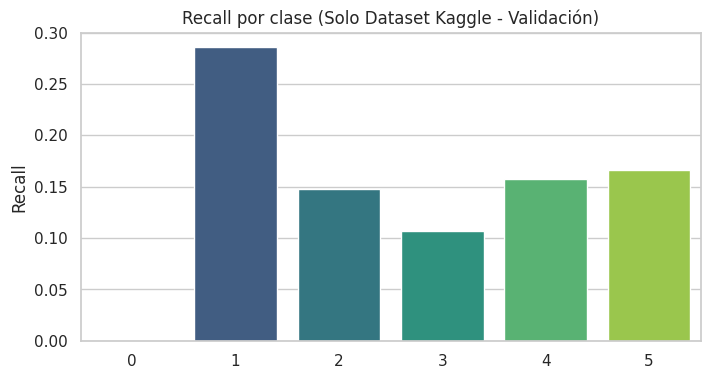

In [ ]:
# Filtrar solo ejemplos de validacion que vienen de la fuente turkish_mt
indices_kaggle_val = [i for i, txt in enumerate(X_val4) if any(triaje[triaje['fuente']=='turkish_mt']['texto'] == txt)]

y_val4_k = y_val4[indices_kaggle_val]
y_pt4_k_val = y_pred_t4[indices_kaggle_val]

print("REPORT SOLO KAGGLE (SISTEMA - VAL)")
print(classification_report(y_val4_k, y_pt4_k_val, digits=3))

# Grafica de barras de acierto por clase en Kaggle
rep_k = classification_report(y_val4_k, y_pt4_k_val, output_dict=True)
plt.figure(figsize=(8, 4))
classes_k = [c for c in rep_k.keys() if c.isdigit()]
vals_k = [rep_k[c]["recall"] for c in classes_k]
sns.barplot(x=classes_k, y=vals_k, palette="viridis")
plt.title("Recall por clase (Solo Dataset Kaggle - Validación)")
plt.ylabel("Recall")
plt.show()

La bajada en rendimiento de nuestro modelo basado en RoBERTa es muy alta. La F1-Macro pasa a un nivel de 0.15. La Recall, tan importante en este caso de uso, ha bajado muchísimo. Incluso aunque la clase 1, que es la más importante, es la más importante, es la que tiene mayor Recall, esta no llega ni a 0.3.

A priori, no sabemos si es que los datos generados con LLMs están sesgando mucho el modelo o es que el conjunto en turco es mucho más difícil, ya sea por su naturaleza o por la calidad de los datos. Vamos a estudiar qué pasa si entrenamos nuestra baseline y modelo del sistema solo con estos datos.

Antes de plantearnos un nuevo modelo entrenado con el dataset turco, ahora que ya hemos hecho todas las comparativas, guardamos nuestro modelo con los resultados:

In [ ]:
trainer_t4.save_model(str(T4_OUT / "roberta_bio_ft"))
tok_t4.save_pretrained(str(T4_OUT / "roberta_bio_ft"))
with open(T4_OUT / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": {str(k):v for k,v in label2id_t4.items()},
               "id2label": id2label_t4}, f, ensure_ascii=False, indent=2)
comp.to_csv(T4_OUT / "comparativa.csv", index=False)
print("Modelo T4 y comparativa guardados en", T4_OUT)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo T4 y comparativa guardados en /content/modelos/t4_triaje


### 4.6. Solo con Dataset de triaje de Kaggle y 200 ejemplos OOD

Vamos a repetir el procedimiento de entrenamiento pero solo con el dataset de triaje de Kaggle y 200 ejemplos elegidos aleatoriamente OOD (para no desbalancear mucho las clases). De esta forma vemos si los datos sintéticos sesgan el modelo o no.

In [ ]:
triaje_red = pd.concat([med_es, df_ood.sample(250, random_state=SEED)])
print(triaje_red.groupby(['fuente','urgencia']).size().unstack(fill_value=0))

urgencia      0   1    2    3    4    5
fuente                                 
ood         250   0    0    0    0    0
turkish_mt    0  62  266  254  170  168


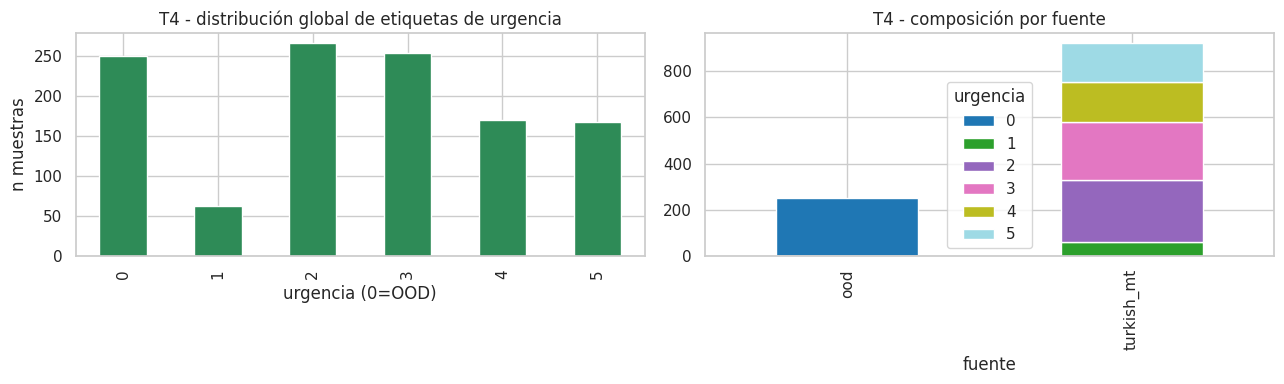

Longitud (palabras) por urgencia:
           count        mean    50%    max
urgencia                                  
0         2000.0  111.651500  134.0  143.0
1          662.0  138.036254  139.5  198.0
2          866.0  105.602771  133.0  198.0
3          854.0  106.949649  136.0  198.0
4          770.0  118.605195  137.0  198.0
5          768.0  118.782552  137.0  198.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
triaje_red['urgencia'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color="seagreen")
axes[0].set_title("T4 - distribución global de etiquetas de urgencia")
axes[0].set_xlabel("urgencia (0=OOD)")
axes[0].set_ylabel("n muestras")

triaje_red.groupby(['fuente','urgencia']).size().unstack(fill_value=0).plot(
    kind='bar', stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("T4 - composición por fuente")
axes[1].set_xlabel("fuente")
plt.tight_layout()
plt.show()

triaje_red['len_words'] = triaje['texto'].astype(str).str.split().str.len()
print("Longitud (palabras) por urgencia:")
print(triaje.groupby('urgencia')['len_words'].describe()[['count','mean','50%','max']])

In [ ]:
X = triaje_red['texto'].astype(str).values
y = triaje_red['urgencia'].astype(int).values

X_tr4, X_tmp, y_tr4, y_tmp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_val4, X_te4, y_val4, y_te4 = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"Train/Val/Test = {len(X_tr4)}/{len(X_val4)}/{len(X_te4)}")


Train/Val/Test = 936/117/117


In [ ]:
# Pipeline de Baseline con TF-IDF y regresion logistica
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(strip_accents="unicode", lowercase=True)),
    ("lr", LogisticRegression(max_iter=2000))
])

# Entrenamiento de la baseline
t0 = time.time()
baseline.fit(X_tr4, y_tr4)
print(f"Tiempo entrenamiento baseline: {time.time()-t0}s")

# Prediccion en test
y_pred_base = baseline.predict(X_te4)
print(classification_report(y_te4, y_pred_base, digits=3))

Tiempo entrenamiento baseline: 3.7230706214904785s
              precision    recall  f1-score   support

           0      0.913     0.840     0.875        25
           1      0.000     0.000     0.000         6
           2      0.436     0.630     0.515        27
           3      0.452     0.560     0.500        25
           4      0.455     0.294     0.357        17
           5      0.846     0.647     0.733        17

    accuracy                          0.581       117
   macro avg      0.517     0.495     0.497       117
weighted avg      0.581     0.581     0.571       117



In [ ]:
# Guardar baseline
T4_OUT_RED = MODELS_DIR / "t4_triaje_red"
T4_OUT_RED.mkdir(exist_ok=True)
joblib.dump(baseline, T4_OUT_RED / "baseline_tfidf_logreg_red.joblib")
print("Baseline T4 guardado.")

Baseline T4 guardado.


In [ ]:
tok_t4 = AutoTokenizer.from_pretrained(T4_MODEL_NAME)

labels_t4 = sorted(np.unique(y).tolist())  # [0,1,2,3,4,5]
label2id_t4 = {int(l): i for i, l in enumerate(labels_t4)}
id2label_t4 = {i: int(l) for l, i in label2id_t4.items()}

def encode_y(y_arr): return np.array([label2id_t4[int(v)] for v in y_arr])

ds_tr_t4  = Dataset.from_dict({"text": list(X_tr4),  "label": encode_y(y_tr4).tolist()})
ds_val_t4 = Dataset.from_dict({"text": list(X_val4), "label": encode_y(y_val4).tolist()})
ds_te_t4  = Dataset.from_dict({"text": list(X_te4),  "label": encode_y(y_te4).tolist()})

MAX_LEN_T4 = 256
def tok_fn_t4(batch): return tok_t4(batch["text"], truncation=True, max_length=MAX_LEN_T4)
ds_tr_t4  = ds_tr_t4.map(tok_fn_t4,  batched=True)
ds_val_t4 = ds_val_t4.map(tok_fn_t4, batched=True)
ds_te_t4  = ds_te_t4.map(tok_fn_t4,  batched=True)

Map:   0%|          | 0/936 [00:00<?, ? examples/s]

Map:   0%|          | 0/117 [00:00<?, ? examples/s]

Map:   0%|          | 0/117 [00:00<?, ? examples/s]

In [ ]:
model_t4 = AutoModelForSequenceClassification.from_pretrained(
    T4_MODEL_NAME, num_labels=len(labels_t4),
    id2label={i: str(l) for i,l in id2label_t4.items()},
    label2id={str(k): v for k,v in label2id_t4.items()},
)

args_t4 = TrainingArguments(
    output_dir=str(T4_OUT_RED / "_trainer"),
    num_train_epochs=15,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    seed=SEED,
    report_to=[],
    fp16=False,
)

trainer_t4 = Trainer(
    model=model_t4, args=args_t4,
    train_dataset=ds_tr_t4, eval_dataset=ds_val_t4,
    processing_class=tok_t4, data_collator=DataCollatorWithPadding(tok_t4),
    compute_metrics=compute_metrics,
)
t0 = time.time()
trainer_t4.train()
print(f"Tiempo de entrenamiento T4 (fine-tuning): {time.time()-t0:.1f}s")



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: PlanTL-GOB-ES/bsc-bio-ehr-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed i

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.513994,1.221887,0.452991,0.313136
2,1.118599,0.997011,0.589744,0.446017
3,0.901776,0.932623,0.623932,0.532213
4,0.763762,0.943559,0.649573,0.553929
5,0.646609,1.074582,0.606838,0.481795
6,0.405812,1.041910,0.632479,0.578015
7,0.293701,1.170842,0.623932,0.559502
8,0.162081,1.318456,0.641026,0.568760
9,0.155797,1.569324,0.623932,0.585931
10,0.072432,1.708382,0.623932,0.557444


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Tiempo de entrenamiento T4 (fine-tuning): 251.9s


In [ ]:
# Predicciones en validacion para el escenario reducido
pred_out_t4_red = trainer_t4.predict(ds_val_t4)
y_pred_t4_enc_red = np.argmax(pred_out_t4_red.predictions, axis=-1)
y_pred_t4_red = np.array([id2label_t4[int(i)] for i in y_pred_t4_enc_red])

print(classification_report(y_val4, y_pred_t4_red, digits=3))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        25
           1      0.400     0.333     0.364         6
           2      0.765     0.500     0.605        26
           3      0.464     0.500     0.481        26
           4      0.381     0.471     0.421        17
           5      0.619     0.765     0.684        17

    accuracy                          0.632       117
   macro avg      0.605     0.595     0.593       117
weighted avg      0.653     0.632     0.634       117




Comprobamos cómo afecta la reducción drástica de datos al perfil de errores de la baseline y del sistema, identificando los pares de clases que más se confunden.


= ANALISIS TOP CONFUSIONES (REDUCIDO)
Baseline (Val): [((4, 3), 9), ((2, 3), 8)]
Sistema (Val): [((3, 4), 8), ((2, 3), 7)]


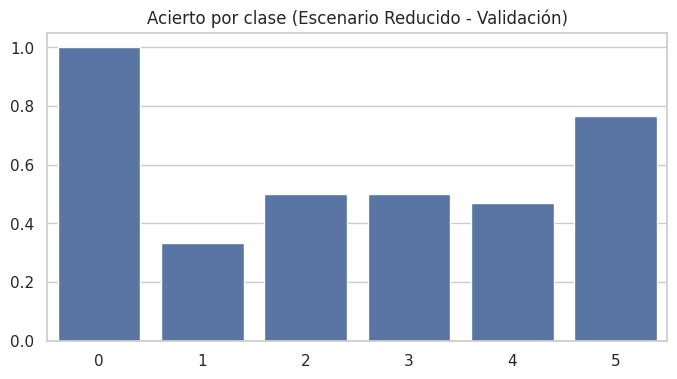

In [ ]:
# Analisis en validacion
y_pred_base_red_val = baseline.predict(X_val4)

print("= ANALISIS TOP CONFUSIONES (REDUCIDO)")
print("Baseline (Val):", top_confusions(y_val4, y_pred_base_red_val, 2))
print("Sistema (Val):", top_confusions(y_val4, y_pred_t4_red, 2))

# Acierto por clase en reducido
report_t4_red_val = classification_report(y_val4, y_pred_t4_red, output_dict=True)
plt.figure(figsize=(8, 4))
classes_r = [c for c in report_t4_red_val.keys() if c.isdigit()]
vals_r = [report_t4_red_val[c]["recall"] for c in classes_r]
sns.barplot(x=classes_r, y=vals_r)
plt.title("Acierto por clase (Escenario Reducido - Validación)")
plt.show()


Resumen visual del impacto de la reducción de datos en la precisión global del triaje.


,modelo,accuracy,macro_f1
0,Baseline TF-IDF + Regresión Logística,0.632479,0.522363
1,RoBERTa,0.632479,0.592505


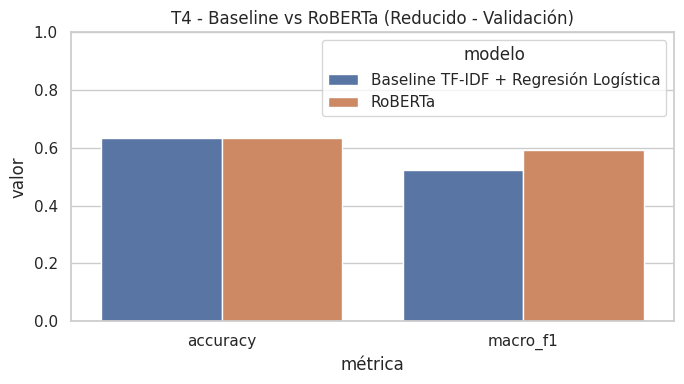

In [ ]:
# Comparativa Reducida en validacion
comp_red = pd.DataFrame([
    {"modelo": "Baseline TF-IDF + Regresión Logística",
     "accuracy": accuracy_score(y_val4, y_pred_base_red_val),
     "macro_f1": f1_score(y_val4, y_pred_base_red_val, average='macro')},
    {"modelo": "RoBERTa",
     "accuracy": accuracy_score(y_val4, y_pred_t4_red),
     "macro_f1": f1_score(y_val4, y_pred_t4_red, average='macro')},
])
display(comp_red)

plt.figure(figsize=(7,4))
comp_red.melt(id_vars="modelo", var_name="métrica", value_name="valor").pipe(
    lambda d: sns.barplot(data=d, x="métrica", y="valor", hue="modelo"))
plt.ylim(0, 1)
plt.title("T4 - Baseline vs RoBERTa (Reducido - Validación)")
plt.tight_layout()
plt.show()


Visualización final de las predicciones para comparar gráficamente dónde falla cada modelo cuando el volumen de entrenamiento es limitado.


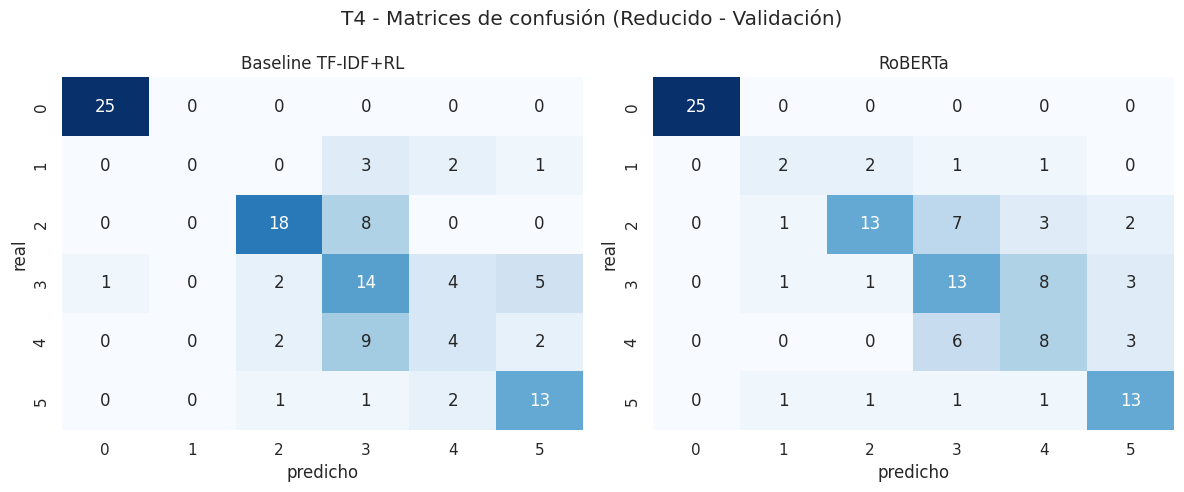

In [ ]:
# Matrices de confusion en validacion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in [(axes[0], y_pred_base_red_val, "Baseline TF-IDF+RL"),
                           (axes[1], y_pred_t4_red,   "RoBERTa")]:
    cm = confusion_matrix(y_val4, y_pred, labels=labels_t4)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_t4, yticklabels=labels_t4, ax=ax, cbar=False)
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(title)
plt.suptitle("T4 - Matrices de confusión (Reducido - Validación)")
plt.tight_layout()
plt.show()

Vemos que, de nuevo, se obtienen resultados muy malos. No es preocupante solo la bajada de rendimiento, sino, especialmente, la bajada en la categoría 1 para la baseline y el modelo que pretendemos usar en el sistema. El patrón de confundir las clases centrales entre sí se sigue manteniendo, aunque ahora está más ecplipsado por el mal rendimiento en la categoría 1. Este, por otra parte, era predecible: el conjunto de datos está muy desbalanceado e incluye muy pocos ejemplos de este tipo.

Todo lo anterior aumenta la duda sobre si los datos generados por LLMs son poco variados o muy fáciles, o por otra parte la calidad del conjunto de datos en turco es mala. Respecto a lo primero, por la forma programática con la que los LLMs hicieron los ejemplos (a base de funciones que combinaban con distintas reglas, numerosas opciones creadas por el LLM de un modo coherente), es natural que estos sean menos variados que los provenientes de la realidad. Por otra parte, podemos examinar la calidad de los datos del conjunto de Kaggle inspeccionando algunas de sus descripciones:

In [ ]:
X_tr4[1:10]

array(['Tengo un dolor en uno de mis ojos y un sarpullido, veo manchas en mi visión.',
       'Tengo frío y temblores todo el tiempo, no soy sexy, tengo moretones y dolores en las puntas de los dedos.',
       'He estado embarazada durante ocho meses y siento contracciones, pero es ligero.',
       'Siento la quemadura en mis dedos de los pies.',
       'Tengo una deformidad en las uñas de los pies, amarillas y frágiles.',
       'Tengo picazón, rojo, ampollas en mi cuerpo, y estas cosas se están esparciendo.',
       'He estado engordando durante el último mes, mi apetito ha aumentado y me siento muy cansada.',
       'Hola, una cosita, vengo a preguntar cómo puedo colaborar como voluntario. Me gustaría ayudar a refugiados en clases de español, llevo años queriéndolo y nunca encuentro el momento de empezar. Quiero decir, tengo disponibilidad limitada, unas cuatro o cinco horas por semana, y prefiero un compromiso estable a algo puntual que no aporte realmente. Me gustaría que me orien

In [ ]:
X_val4[1:10]

array(['Tengo un sarpullido en los ojos, un sarpullido, picazón y fuego, y mis ojos se pegan por la mañana.',
       'Mis ojos están cansados, quemados y borrosos después de mirar la computadora.',
       'Tengo temblores en la mano, y me muevo lentamente, y estoy perdiendo el equilibrio al caminar.',
       'Hola, eh, mire, tengo un problema con un aparato de casa, a ver si me echan una mano. Resulta que el televisor smart se calienta muchísimo, y llevo así desde la última actualización que se hizo hace cosa de una semana. No sé, he intentado reiniciarlo, restablecerlo de fábrica y mirar tutoriales en YouTube, pero ninguno coincide con mi modelo exacto. El aparato lo compré hace dos años, todavía debería estar en garantía porque era de tres, aunque no encuentro la factura por casa. No sé, no sé si llevarlo al servicio técnico, comprar uno nuevo o esperar a que saquen una actualización que lo arregle. No quiero gastar de más. Si me pueden indicar qué hacer, lo agradezco mucho. Llevo ti

Vemos que estas, no solo son escuetas, sino que en muchos casos parecen algo antinaturales por la traducción. En este sentido, el conjunto de datos turco tampoco parece de ser de muy buena calidad y sí bastante difícil: es poco expresivo, con frases cortas, sufre de mucho desbalanceo (perjudicando bastante a la clase más importante) y además se pierde información en la traducción. Esto, naturalmente, hace la bajada en rendimiento casi inevitable.